# Experiment 2 - Matched Parameters

By default the two libraries run at different ring dimensions (8192 for TenSEAL, 16384 for OpenFHE) and different scaling factors, so a direct comparison measures the settings as well as the code.

This experiment pins OpenFHE to TenSEAL's ring dimension and scaling factor, and sweeps OpenFHE's four scaling techniques.

Corresponds to Experiment 2 in the report, *The Libraries, or the Parameters?*

## 1. Install and load the project


In [1]:
import subprocess
import sys

# TenSEAL publishes real platform-tagged wheels (win_amd64 / manylinux / macosx,
# CPython 3.8-3.12), so it installs anywhere. Pinned to the version the report used.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "tenseal==0.3.15", "numpy", "matplotlib"], check=True)

# OpenFHE is the opposite. Every OpenFHE distribution on PyPI is tagged
# `py3-none-any`, but the payload is Linux ELF binaries built against one
# specific CPython. The 1.4.1 line, which the report used, is:
#
#     openfhe==1.4.1.0.20.4   Ubuntu 20.04   cpython-38    requires_python >=3.8
#     openfhe==1.4.1.0.22.4   Ubuntu 22.04   cpython-310   requires_python >=3.10
#     openfhe==1.4.1.0.24.4   Ubuntu 24.04   cpython-312   requires_python >=3.12
#
# Those bounds are `>=`, so an unpinned install takes the newest wheel whose
# bound this interpreter satisfies -- which need not be built for it. On 3.10
# and 3.12 that happens to land on a valid build; on 3.9, 3.11 and 3.13 it does
# not (3.11 resolves to the cpython-310 wheel openfhe==1.5.1.0.22.4), installs
# with no warning, and fails at *import*. Pinning also keeps the OpenFHE version
# identical to the report's.
OPENFHE_WHEELS = {(3, 8): "1.4.1.0.20.4", (3, 10): "1.4.1.0.22.4", (3, 12): "1.4.1.0.24.4"}
_py = sys.version_info[:2]
_wheel = OPENFHE_WHEELS.get(_py)

if sys.platform != "linux":
    print(f"Skipping OpenFHE: no wheel has ever been published for {sys.platform!r}. "
          "The plaintext and TenSEAL columns still run.")
elif _wheel is None:
    _have = ", ".join(f"{a}.{b}" for a, b in sorted(OPENFHE_WHEELS))
    print(f"Skipping OpenFHE: no build exists for CPython {_py[0]}.{_py[1]} "
          f"(builds exist for {_have}). The plaintext and TenSEAL columns still run.")
else:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    f"openfhe=={_wheel}"], check=True)
    print(f"Installed openfhe=={_wheel} for CPython {_py[0]}.{_py[1]}.")

Installed openfhe==1.4.1.0.24.4 for CPython 3.12.


In [2]:
import os
import subprocess
import sys

REPO = "https://github.com/To2004/confidential-computing-project.git"

# Works both on a fresh Colab runtime and inside a local checkout.
if not os.path.exists("src/benchmark_harness.py"):
    if not os.path.exists("confidential-computing-project"):
        subprocess.run(["git", "clone", "-q", REPO], check=True)
    os.chdir("confidential-computing-project")

# Absolute, so imports survive a later change of directory, and guarded so
# re-running this cell does not stack duplicate entries.
SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# Write this notebook's output to its own directory, so running it does not
# overwrite the results and figures the report was built from.
import benchmark_harness as harness
import project_paths

os.makedirs("notebook_output", exist_ok=True)
project_paths.RESULTS_DIR = "notebook_output"
project_paths.FIGURES_DIR = "notebook_output"

print("working directory:", os.getcwd())
print("report uses", harness.DEFAULT_REPEATS, "repetitions per measurement")

working directory: /mnt/c/Users/user/Desktop/coursework/confidential-computing-project
report uses 1000 repetitions per measurement


## 2. What this experiment changes

Experiment 1 found TenSEAL faster on every arithmetic operation. That comparison was
confounded. OpenFHE derived ring dimension **16384** and a **2^50** scale from the depth and
security level it was asked for, against TenSEAL's **8192** and **2^40** - roughly twice the
polynomial work per operation, while carrying ten more bits of precision per value. OpenFHE was
not slower at the same job; it was doing a larger one.

This experiment re-runs OpenFHE pinned to TenSEAL's parameters, and additionally sweeps
OpenFHE's **scaling technique** - an internal control over how it manages the scaling factor
between multiplications, which TenSEAL does not expose at all.

In [3]:
import notebook_tools as nt

nt.show_source(
    "matched_comparison.py", "openfhe_arm",
    note="The two lines that carry this experiment are `params.SetRingDim(ring_dim)` and "
         "`params.SetSecurityLevel(SecurityLevel.HEStd_NotSet)`. Everything else is the same "
         "operation dict Experiment 1 uses.")

**`src/matched_comparison.py` — `openfhe_arm`**  
The two lines that carry this experiment are `params.SetRingDim(ring_dim)` and `params.SetSecurityLevel(SecurityLevel.HEStd_NotSet)`. Everything else is the same operation dict Experiment 1 uses.

```python
def openfhe_arm(vector, repeats, warmup, scaling_technique=None,
                ring_dim=POLY_MODULUS_DEGREE, scale_bits=SCALE_BITS,
                first_mod_bits=FIRST_MOD_BITS, label=""):
    n = len(vector)
    params = CCParamsCKKSRNS()
    params.SetMultiplicativeDepth(MULT_DEPTH)
    params.SetScalingModSize(scale_bits)
    params.SetFirstModSize(first_mod_bits)
    params.SetBatchSize(8)

    if ring_dim is None:
        # Let OpenFHE pick the ring dimension at 128-bit security.
        params.SetSecurityLevel(fhe.HEStd_128_classic)
    else:
        # Pinning the ring dimension disables the library's own security check.
        params.SetRingDim(ring_dim)
        params.SetSecurityLevel(SecurityLevel.HEStd_NotSet)

    if scaling_technique is not None:
        params.SetScalingTechnique(getattr(fhe.ScalingTechnique, scaling_technique))

    cc = GenCryptoContext(params)
    for feature in (PKESchemeFeature.PKE, PKESchemeFeature.KEYSWITCH,
                    PKESchemeFeature.LEVELEDSHE, PKESchemeFeature.ADVANCEDSHE):
        cc.Enable(feature)
    keys = cc.KeyGen()
    cc.EvalMultKeyGen(keys.secretKey)
    cc.EvalSumKeyGen(keys.secretKey)

    ct = cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(vector))
    ct2 = cc.Encrypt(keys.publicKey,
                     cc.MakeCKKSPackedPlaintext(_second_vector(vector)))

    operations = {
        "encrypt": lambda: cc.Encrypt(keys.publicKey,
                                      cc.MakeCKKSPackedPlaintext(vector)),
        "add": lambda: cc.EvalAdd(ct, ct),
        "mul": lambda: cc.EvalMult(ct, ct),
        "sum": lambda: cc.EvalSum(ct, n),
        "dot": lambda: cc.EvalInnerProduct(ct, ct2, n),
        "decrypt": lambda: cc.Decrypt(keys.secretKey, ct),
    }
    results = harness.benchmark_operations(operations, repeats=repeats, warmup=warmup,
                                           label=label or "OpenFHE",
                                           keep_samples=False)

    out = cc.Decrypt(keys.secretKey, cc.EvalMult(ct, ct))
    out.SetLength(n)
    results["mul_max_error"] = max(
        abs(a - v * v) for a, v in zip(out.GetRealPackedValue(), vector))
    results["ring_dimension"] = cc.GetRingDimension()
    # Excludes the auxiliary primes used by HYBRID key switching.
    results["modulus_bits"] = int(cc.GetModulus()).bit_length()
    results["scale_bits"] = scale_bits
    results["scaling_technique"] = scaling_technique or "FLEXIBLEAUTOEXT (default)"
    results["arm"] = label
    results["security_level"] = ("HEStd_128_classic" if ring_dim is None
                                 else "HEStd_NotSet (ring dimension pinned)")
    return results
```

### The trade this experiment makes, stated plainly

Asked for a ring dimension of 8192 at these moduli, OpenFHE **raises an error** rather than
accepting them: 8192 does not comply with the 128-bit standard here. The matched arm runs only
because the security level was explicitly relaxed to `HEStd_NotSet`, the setting OpenFHE
documents for prototyping.

So this experiment reports what the libraries do at **equal** parameters, not at equally
**secure** ones. That is a deliberate trade to isolate one variable, and it is disclosed as
such in the report. `probe_library_chosen_ring` records what OpenFHE picks when left alone.

In [4]:
nt.show_source(
    "matched_comparison.py", "probe_library_chosen_ring",
    note="Run without a pinned ring dimension, so the returned value is what the library "
         "considers the smallest 128-bit-secure ring for these moduli.")

**`src/matched_comparison.py` — `probe_library_chosen_ring`**  
Run without a pinned ring dimension, so the returned value is what the library considers the smallest 128-bit-secure ring for these moduli.

```python
def probe_library_chosen_ring(scale_bits=SCALE_BITS, first_mod_bits=FIRST_MOD_BITS):
    """Ring dimension OpenFHE picks at HEStd_128_classic, per scaling technique.

    A chosen ring larger than POLY_MODULUS_DEGREE means the pinned arm is below
    128-bit security.
    """
    findings = {}
    for technique in SCALING_TECHNIQUES:
        params = CCParamsCKKSRNS()
        params.SetMultiplicativeDepth(MULT_DEPTH)
        params.SetScalingModSize(scale_bits)
        params.SetFirstModSize(first_mod_bits)
        params.SetBatchSize(8)
        params.SetSecurityLevel(fhe.HEStd_128_classic)
        params.SetScalingTechnique(getattr(fhe.ScalingTechnique, technique))
        cc = GenCryptoContext(params)
        cc.Enable(PKESchemeFeature.PKE)
        findings[technique] = {
            "library_chosen_ring": cc.GetRingDimension(),
            "pinned_ring": POLY_MODULUS_DEGREE,
            "modulus_bits": int(cc.GetModulus()).bit_length(),
            "pinned_arm_is_128_bit": cc.GetRingDimension() <= POLY_MODULUS_DEGREE,
        }
    return findings
```

## 3. Check which libraries loaded

OpenFHE only publishes Linux binaries, and each build targets one specific
CPython (3.8, 3.10 or 3.12). On any other platform or Python version the
install cell above skips it, so it will not be listed as available here.

This experiment needs OpenFHE and will not run without it.

In [5]:
import importlib

for name in ("tenseal", "openfhe"):
    try:
        importlib.import_module(name)
        print(f"{name}: available")
    except Exception as exc:
        print(f"{name}: not available -- {exc}")

# This experiment measures OpenFHE itself, so stop here with a clear message
# rather than letting the benchmark below fail inside a subprocess.
try:
    import openfhe
except ImportError:
    raise RuntimeError(
        "This notebook measures OpenFHE itself, and OpenFHE did not import. "
        "OpenFHE publishes Linux-only wheels, each built against one specific "
        "CPython (3.8, 3.10 or 3.12 -- see the install cell above); it cannot "
        "run on Windows or macOS at all. Use WSL2 or a Linux runtime whose "
        "Python matches one of those builds, or the he38 environment described "
        "in the project README."
    ) from None

tenseal: available


openfhe: available


## 4. Run the experiment

`REPEATS` is the number of timed repetitions per measurement. The report uses 1000 on a reserved compute node; this notebook uses fewer so it finishes in a few minutes. The numbers it prints will therefore be noisier than the ones in the report.

In [6]:
REPEATS = 30

!"{sys.executable}" src/matched_comparison.py --repeats {REPEATS} --warmup 5 --output notebook_output/matched_comparison_results.json

                                    Matched-Parameter Comparison                                    
TenSEAL reference: poly_modulus_degree=8192, coeff_mod=[60, 40, 40, 60], scale=2^40
Timing: 30 repetitions per operation, 5 discarded warm-up calls

Security check — what ring dimension does OpenFHE choose itself?


  FIXEDMANUAL      library picks ring  16384  (we pin 8192)  -> pinned arm is NOT 128-bit secure
  FIXEDAUTO        library picks ring  16384  (we pin 8192)  -> pinned arm is NOT 128-bit secure
  FLEXIBLEAUTO     library picks ring  16384  (we pin 8192)  -> pinned arm is NOT 128-bit secure
  FLEXIBLEAUTOEXT  library picks ring  16384  (we pin 8192)  -> pinned arm is NOT 128-bit secure

TenSEAL (reference):


  [TenSEAL] encrypt      timing 30 reps (+5 warm-up)...

 mean    2.8668 ms ± 0.1359 (median 2.7667, 13.2% rel. sd)  <-- DRIFT
  [TenSEAL] add          timing 30 reps (+5 warm-up)... mean    0.0335 ms ± 0.0004 (median 0.0327, 3.5% rel. sd)  <-- DRIFT
  [TenSEAL] mul          timing 30 reps (+5 warm-up)...

 mean    1.9082 ms ± 0.0461 (median 1.8882, 6.8% rel. sd)
  [TenSEAL] sum          timing 30 reps (+5 warm-up)...

...

 mean   31.4099 ms ± 8.0790 (median 26.9371, 71.9% rel. sd)
  [OpenFHE matched (FLEXIBLEAUTOEXT)] sum          timing 30 reps (+5 warm-up)...

 mean   66.2624 ms ± 6.0809 (median 66.3422, 25.6% rel. sd)  <-- DRIFT
  [OpenFHE matched (FLEXIBLEAUTOEXT)] dot          timing 30 reps (+5 warm-up)...

 mean   98.4525 ms ± 14.1514 (median 87.1913, 40.2% rel. sd)  <-- DRIFT
  [OpenFHE matched (FLEXIBLEAUTOEXT)] decrypt      timing 30 reps (+5 warm-up)...

 mean    5.7409 ms ± 0.9694 (median 5.2489, 47.2% rel. sd)  <-- DRIFT
  [!] first/second-half means differ by more than 5.0% for: encrypt, sum, dot, decrypt
      Treat those means as contaminated by machine load, not as steady-state cost.

                           Multiplication: time and precision across arms                           
Arm                                            Ring  Scale   Mul (ms)  vs TenSEAL   Mul errorvs TenSEAL
----------------------------------------------------------------------------------------------------
TenSEAL (reference configuration)              8192     40      1.908       1.00x    3.38e-06        1x
OpenFHE (library-chosen: ring 16384, scale    16384     50     27.252      14.28x    1.12e-12  3022882x
OpenFHE matched (FIXEDMANUAL)                  8192     40     22.735      11.91x    9.36e-09      361x
OpenFHE matched (FIXEDAUTO)                    8192     40     23.481      12.31x    1.20e-08      283x
OpenFHE matched (FLEXIBLEAUTO)       


Results saved to notebook_output/matched_comparison_results.json


## 5. Results


Saved notebook_output/chart_matched_comparison.png


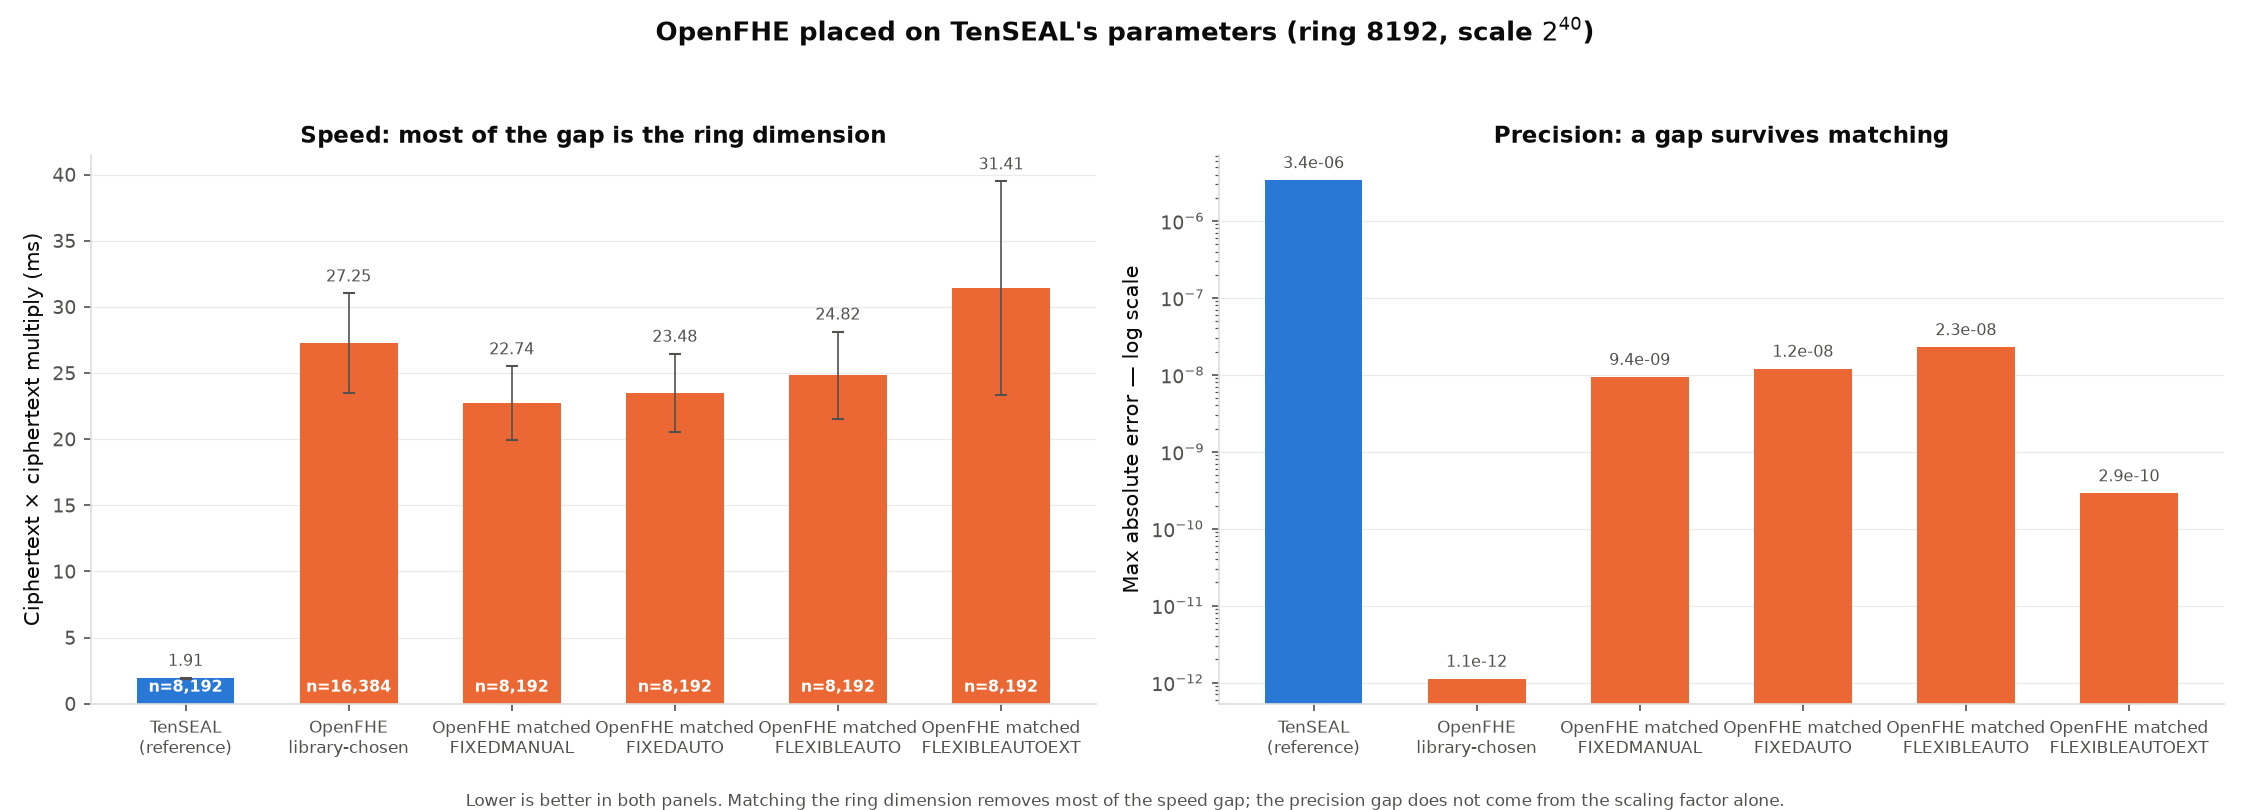

In [7]:
import plot_results as pr
from IPython.display import Image, display

pr.apply_style()
pr.chart_matched(pr.load("matched_comparison_results.json"))
display(Image("notebook_output/chart_matched_comparison.png"))